In [ ]:
import numpy as  np
import cv2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


array([[[234, 229, 230],
        [234, 229, 230],
        [235, 229, 230],
        ...,
        [255, 240, 237],
        [255, 242, 234],
        [255, 244, 232]],

       [[236, 230, 231],
        [236, 230, 231],
        [236, 230, 231],
        ...,
        [255, 242, 234],
        [255, 243, 233],
        [255, 243, 231]],

       [[235, 229, 230],
        [235, 229, 230],
        [235, 229, 230],
        ...,
        [255, 242, 230],
        [255, 242, 230],
        [253, 241, 231]],

       ...,

       [[114, 118, 123],
        [100, 104, 109],
        [107, 111, 116],
        ...,
        [102, 104, 104],
        [109, 111, 112],
        [111, 113, 114]],

       [[113, 125, 129],
        [121, 130, 134],
        [116, 122, 127],
        ...,
        [107, 109, 110],
        [101, 103, 104],
        [ 98, 100, 101]],

       [[102, 126, 126],
        [120, 132, 136],
        [112, 116, 121],
        ...,
        [103, 105, 106],
        [105, 107, 108],
        [ 98, 100, 101]]], dtype=uint8)
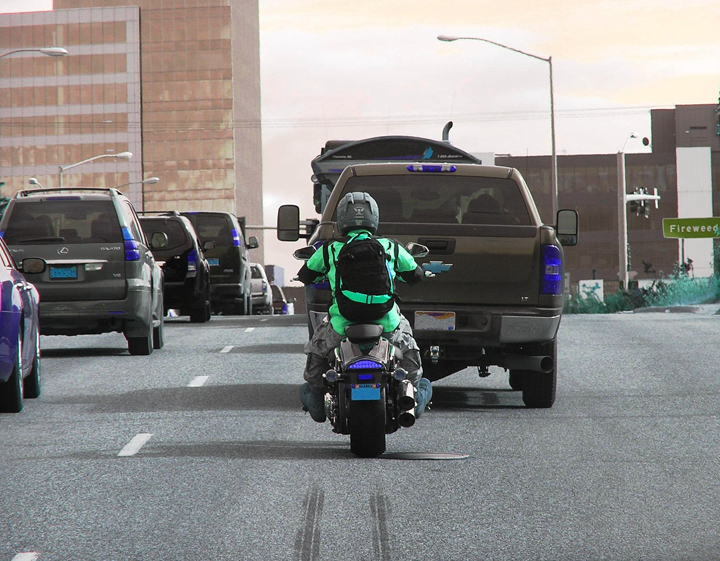

In [ ]:
main_path = "/content/drive/MyDrive/CEI /Inteligencia Artificial/TEMA 5 Computer Vision/3. Yolo/images/"

# load the image to detect, get width, height
path = 'scene2.jpg'
full_path = main_path + path

img_to_detect = cv2.imread(full_path)
img_height = img_to_detect.shape[0]
img_width = img_to_detect.shape[1]
img_to_detect

### Crear el “blob” y definir las clases de YOLO

Este bloque prepara la imagen para que YOLO (You Only Look Once) pueda analizarla y define las 80 categorías que el modelo reconoce.

**Entradas / Salidas:**

- Entrada: una imagen (`img_to_detect`).
    
- Salida: un _blob_ normalizado (`img_blob`) listo para la red y la lista de clases detectables.
    

**Puntos clave:**

- El _blob_ es una versión de la imagen ajustada y escalada para que la red la procese igual que en su entrenamiento.
    
- El valor `0.003922` normaliza la imagen dividiendo entre 255 para dejar los colores entre 0 y 1.
    
- El tamaño 416×416 es uno de los recomendados: más grande = más precisión pero menos velocidad.
    

**Consejo práctico:**  
Si necesitas más rapidez, baja el tamaño del blob (320×320) antes de probar otras optimizaciones.

### ¿Para qué definimos la lista de *class_labels*?
Es la lista de las 80 categorías que YOLO (You Only Look Once) sabe reconocer en su versión entrenada COCO.

- Cada predicción de YOLO devuelve un **ID numérico** de clase; esta lista permite traducirlo a un **nombre legible**.  
- El orden de la lista **debe coincidir exactamente** con el orden usado para entrenar YOLO.  
- Sin esta lista, YOLO detectaría objetos, pero no podrías saber si es un perro, una mesa o un coche.


In [ ]:
# convert to blob to pass into model
img_blob = cv2.dnn.blobFromImage(img_to_detect, 0.003922, (416, 416), swapRB=True, crop=False)
#recommended by yolo authors, scale factor is 0.003922=1/255, width,height of blob is 320,320
#accepted sizes are 320×320,416×416,609×609. More size means more accuracy but less speed

# set of 80 class labels
class_labels = ["person","bicycle","car","motorcycle","airplane","bus","train","truck","boat",
                "trafficlight","firehydrant","stopsign","parkingmeter","bench","bird","cat",
                "dog","horse","sheep","cow","elephant","bear","zebra","giraffe","backpack",
                "umbrella","handbag","tie","suitcase","frisbee","skis","snowboard","sportsball",
                "kite","baseballbat","baseballglove","skateboard","surfboard","tennisracket",
                "bottle","wineglass","cup","fork","knife","spoon","bowl","banana","apple",
                "sandwich","orange","broccoli","carrot","hotdog","pizza","donut","cake","chair",
                "sofa","pottedplant","bed","diningtable","toilet","tvmonitor","laptop","mouse",
                "remote","keyboard","cellphone","microwave","oven","toaster","sink","refrigerator",
                "book","clock","vase","scissors","teddybear","hairdrier","toothbrush"]

### Preparar una paleta de colores para las cajas  
Crea una lista de colores en formato "R,G,B", la convierte a arrays numéricos y la repite para tener suficientes colores por clase.

**Entradas / Salidas:** Entrada: lista de strings `class_colors`; Salida: `class_colors` como `np.ndarray` de shape (80,3) (colores enteros).

1. `split` separa cada string en R,G,B y `astype("int")` lo convierte a números.  
2. `np.array(...)` unifica la lista en una matriz que OpenCV acepta para dibujar.  
3. `np.tile(...,(16,1))` repite la paleta 16 veces para cubrir las 80 clases (5 colores × 16 = 80).



In [ ]:
#Declare List of colors as an array
#Green, Blue, Red, cyan, yellow, purple
#Split based on ',' and for every split, change type to int
#convert that to a numpy array to apply color mask to the image numpy array
class_colors = ["0,255,0","0,0,255","255,0,0","255,255,0","0,255,255"]
class_colors = [np.array(every_color.split(",")).astype("int") for every_color in class_colors]
class_colors = np.array(class_colors)
class_colors = np.tile(class_colors,(16,1))

### Cargar el modelo YOLOv3 preentrenado  
Este bloque abre los archivos del modelo (configuración y pesos) para dejar la red lista para hacer detecciones.

**Entradas / Salidas:** Entrada: rutas del `.cfg` y `.weights`; Salida: `yolo_model` cargado en memoria.

1. El archivo `.cfg` describe la estructura de la red (capas, tamaños, conexiones).  
2. El archivo `.weights` contiene lo que la red aprendió durante el entrenamiento.  
3. `readNetFromDarknet` combina ambos y genera un modelo listo para recibir el *blob* de entrada.


In [ ]:
# Loading pretrained model
# input preprocessed blob into model and pass through the model
# obtain the detection predictions by the model using forward() method
model3_path = "/content/drive/MyDrive/CEI /Inteligencia Artificial/TEMA 5 Computer Vision/3. Yolo/model-v3/"
yolo_model = cv2.dnn.readNetFromDarknet(model3_path+'yolov3.cfg',model3_path+'yolov3.weights')

### Obtener las capas de la red y los índices de salida  
Este bloque recupera los nombres de todas las capas de YOLO y los índices de las capas finales donde se generan las detecciones.

1. `getLayerNames()` devuelve una lista con el nombre de cada capa de la red en orden.  
2. `getUnconnectedOutLayers()` indica qué capas producen la salida final (predicciones).  
3. Estos índices luego se usan para decirle a `forward()` qué capas queremos calcular.


### ¿Por qué necesitamos los nombres de las capas y los índices?
Porque YOLO genera sus predicciones **solo en algunas capas finales**, y debemos decirle a OpenCV cuáles son para que nos devuelva esas salidas.

**Puntos clave:**  
1. `getLayerNames()` nos da la lista completa, y así podemos localizar fácilmente las capas de salida usando sus índices.  
2. `getUnconnectedOutLayers()` nos dice **exactamente** qué capas producen las detecciones (son 3 en YOLOv3).  
3. Con esos nombres, `forward(yolo_output_layer)` calcula **solo** las salidas relevantes, evitando procesar capas innecesarias.


Sin esta identificación, `forward()` devolvería resultados incompletos o fallaría porque no sabría qué capas contienen las detecciones finales.


In [ ]:
# Obtener nombres de las capas y normalizar índices de salida (compatible con todas las versiones)
yolo_layers = yolo_model.getLayerNames()
output_layer_indices = yolo_model.getUnconnectedOutLayers()

### Normalizar los índices de salida de YOLO  
Este bloque convierte los índices de las capas de salida a una lista simple de enteros, sin importar el formato en que OpenCV los devuelva.

**Puntos clave:**  
1. OpenCV puede devolver los índices como escalar, lista, tupla o array 2D; este código los unifica.  
2. `flatten().tolist()` asegura que incluso un array como `[[200], [227], [254]]` se convierta en `[200, 227, 254]`.  
3. Convertir todo a enteros evita errores al usarlos para seleccionar capas luego.

**Consejo práctico:** Imprime `output_layer_indices` antes y después de normalizar para entender qué formato genera tu versión de OpenCV.


In [ ]:
output_layer_indices

array([200, 227, 254], dtype=int32)

In [ ]:
# Normalizar a lista de ints (soporta scalar, array 2D, array 1D, list, tuple)
if isinstance(output_layer_indices, np.ndarray):
    output_layer_indices = output_layer_indices.flatten().tolist()
elif isinstance(output_layer_indices, (list, tuple)):
    output_layer_indices = list(output_layer_indices)
else:
    output_layer_indices = [int(output_layer_indices)]

output_layer_indices = [int(i) for i in output_layer_indices]  # asegurar enteros

In [ ]:
output_layer_indices

[200, 227, 254]

### Ejecutar YOLO sobre la imagen  
Este bloque envía el *blob* al modelo YOLO y obtiene únicamente las capas donde están las detecciones finales.

**Puntos clave:**  
1. `setInput(img_blob)` carga la imagen preprocesada en la red (YOLO = *You Only Look Once*).  
2. `forward(yolo_output_layer)` ejecuta la red y calcula solo las capas de salida necesarias.  
3. `obj_detection_layers` contiene las predicciones: cajas, confianzas y probabilidades de clase.


In [ ]:
yolo_output_layer = [yolo_layers[i - 1] for i in output_layer_indices]

# input preprocessed blob into model and pass through the model
yolo_model.setInput(img_blob)
# obtain the detection layers by forwarding through till the output layer
obj_detection_layers = yolo_model.forward(yolo_output_layer)

### Inicializar listas para NMS (Non-Maximum Suppression)  
Se crean listas vacías para recoger las clases, las cajas y las confidencias antes de aplicar NMS (supresión de no-máximos).

**Entradas / Salidas:** Entrada: detecciones extraídas del modelo; Salida: `class_ids_list`, `boxes_list`, `confidences_list` rellenas para el filtrado posterior.  

1. `class_ids_list` almacenará el ID de la clase para cada detección (para hacer NMS por clase).  
2. `boxes_list` guardará las cajas en coordenadas (centro/ancho/alto o x,y,w,h) para calcular solapamientos.  
3. `confidences_list` guarda la confianza de cada detección; NMS usa estas puntuaciones para elegir la caja ganadora.  


In [ ]:
############## NMS Change 1 ###############
# initialization for non-max suppression (NMS)
# declare list for [class id], [box center, width & height[], [confidences]
class_ids_list = []
boxes_list = []
confidences_list = []
############## NMS Change 1 END ###########

### Guardar datos para aplicar NMS  
Aquí se guardan las detecciones válidas en tres listas separadas para poder filtrar cajas solapadas más adelante.

**Puntos clave:**  
1. `class_ids_list` almacena la clase de cada detección para aplicar NMS por clase si es necesario.  
2. `confidences_list` guarda la confianza como `float`, porque NMS necesita comparar puntuaciones.  
3. `boxes_list` guarda cada caja como `[x, y, width, height]`, ya en píxeles y como enteros.

**Consejo práctico:**  
Asegúrate de que `start_x_pt` y `start_y_pt` nunca sean negativos usando `max(0, valor)` antes de guardar las cajas.


In [ ]:
from google.colab.patches import cv2_imshow

# loop over each of the layer outputs
for object_detection_layer in obj_detection_layers:
	# loop over the detections
    for object_detection in object_detection_layer:

        # obj_detections[1 to 4] => will have the two center points, box width and box height
        # obj_detections[5] => will have scores for all objects within bounding box
        all_scores = object_detection[5:]
        predicted_class_id = np.argmax(all_scores)
        prediction_confidence = all_scores[predicted_class_id]

        # take only predictions with confidence more than 20%
        if prediction_confidence > 0.60:
            #get the predicted label
            predicted_class_label = class_labels[predicted_class_id]
            #obtain the bounding box co-oridnates for actual image from resized image size
            bounding_box = object_detection[0:4] * np.array([img_width, img_height, img_width, img_height])
            (box_center_x_pt, box_center_y_pt, box_width, box_height) = bounding_box.astype("int")
            start_x_pt = int(box_center_x_pt - (box_width / 2))
            start_y_pt = int(box_center_y_pt - (box_height / 2))

            ############## NMS Change 2 ###############
            #save class id, start x, y, width & height, confidences in a list for nms processing
            #make sure to pass confidence as float and width and height as integers
            class_ids_list.append(predicted_class_id)
            confidences_list.append(float(prediction_confidence))
            boxes_list.append([start_x_pt, start_y_pt, int(box_width), int(box_height)])
            ############## NMS Change 2 END ###########

### Aplicar NMS y dibujar solo las cajas seleccionadas  
Este bloque aplica Non-Maximum Suppression (NMS) para eliminar cajas solapadas débiles y dibuja únicamente las detecciones retenidas.

**Entradas / Salidas:** Entrada: `boxes_list`, `confidences_list`, `class_ids_list`; Salida: `img_to_detect` con cajas finales mostradas y mensajes en consola.

**Puntos clave:**  
1. `cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)` filtra cajas usando umbral de confianza (0.5) e IOU (0.4).  
2. El código maneja distintos formatos de `max_value_ids` (lista, ndarray 2D/1D) y evita fallo si no quedan cajas.  
3. Actualmente NMS se aplica globalmente; para evitar eliminar objetos distintos cercanos conviene hacer NMS **por clase** (filtrar por `class_ids_list` y aplicar NMS en cada grupo).

**Consejo práctico:**  
Prueba agrupar por `predicted_class_id` y usar `conf_thresh≈0.3–0.5` e `iou_thresh≈0.3–0.5`; además clampea coordenadas dentro de la imagen antes de llamar a NMS.


### ¿Por qué aplicamos NMS?  
NMS (*Non-Maximum Suppression*) sirve para quedarnos con **una sola caja por objeto** cuando YOLO genera muchas cajas casi iguales.

**Puntos clave:**  
1. YOLO suele proponer **varias cajas para el mismo objeto**, cada una con una confianza distinta.  
2. Las “cajas solapadas débiles” son cajas que se superponen mucho con otra más confiada: representan el *mismo* objeto, pero peor.  
3. NMS compara ese solapamiento (IOU) y **elimina todas las cajas que se solapan demasiado** con la mejor, quedándose solo con la más fiable.

**Consejo práctico:**  
Ajusta los umbrales (confianza e IOU) si ves muchas cajas repetidas o si desaparecen objetos que sí querías detectar.


predicted object car: 99.14%
predicted object person: 98.43%
predicted object car: 97.37%
predicted object car: 95.33%
predicted object motorcycle: 91.93%
predicted object car: 87.79%
predicted object truck: 82.44%


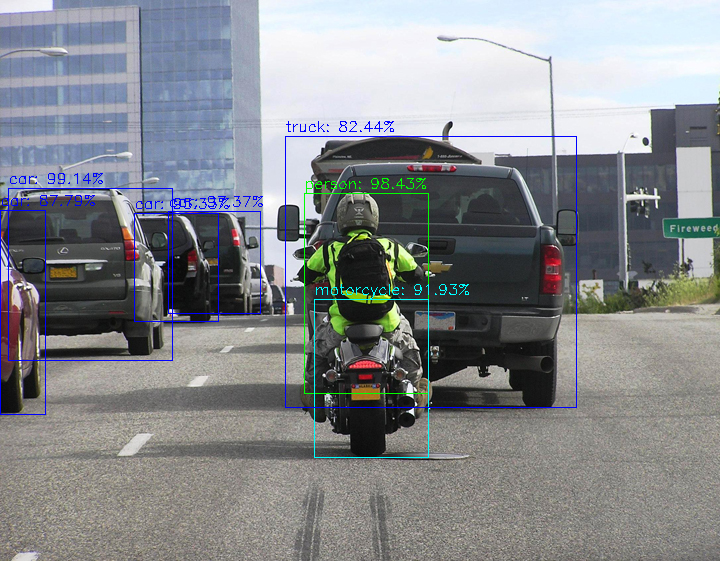

In [ ]:
############## NMS Change 3 ###############
# Applying the NMS will return only the selected max value ids while suppressing the non maximum (weak) overlapping bounding boxes
# Non-Maxima Suppression confidence set as 0.5 & max_suppression threhold for NMS as 0.4 (adjust and try for better perfomance)
max_value_ids = cv2.dnn.NMSBoxes(boxes_list, confidences_list, 0.5, 0.4)

# Defensive handling:
if max_value_ids is None or len(max_value_ids) == 0:
    print("No boxes after NMS")
else:
    # max_value_ids puede ser lista de ints, ndarray (N,1) o ndarray (N,)
    # Convertir todo a 1D array de indices
    import numpy as np
    if isinstance(max_value_ids, (list, tuple)):
        idxs = np.array(max_value_ids).reshape(-1)
    else:
        # es numpy array; aplanar y convertir a 1D
        idxs = max_value_ids.flatten()

    # iterar por indices
    for i in idxs:
        # i puede ser numpy.int64; convertir a int por seguridad
        i = int(i)
        box = boxes_list[i]
        start_x_pt = int(box[0])
        start_y_pt = int(box[1])
        box_width = int(box[2])
        box_height = int(box[3])

        predicted_class_id = class_ids_list[i]
        predicted_class_label = class_labels[predicted_class_id]
        prediction_confidence = confidences_list[i]

        end_x_pt = start_x_pt + box_width
        end_y_pt = start_y_pt + box_height

        box_color = class_colors[predicted_class_id]
        box_color = [int(c) for c in box_color]

        label_text = "{}: {:.2f}%".format(predicted_class_label, prediction_confidence * 100)
        print("predicted object {}".format(label_text))

        cv2.rectangle(img_to_detect, (start_x_pt, start_y_pt), (end_x_pt, end_y_pt), box_color, 1)
        cv2.putText(img_to_detect, label_text, (start_x_pt, start_y_pt-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, box_color, 1)

    # show output
    cv2_imshow(img_to_detect)